In [1]:
from pathlib import Path
from IPython.display import display_markdown

import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import polars.selectors as cs
import seaborn as sns
from scipy.stats import mannwhitneyu, pearsonr, wilcoxon

In [2]:
results_path = Path('../../results/quantum_entropy')
corpora = [
    'semeval',
    'humicroedit',
    'expunations',
    'joker_clef_en',
    'joker_clef_es',
    'HAHA@IberLEF2021',
    'HUHU@IberLEF2023',
    'joker_clef_fr',
    'joker_clef_pt',
    'clemencio',
    'puntuguese',
    'chumor'
]
metrics = ['QE-U + GloVe', 'QE-I + GloVe']

In [3]:
dfs = []
for corpus in corpora:
    df = (pl.read_ndjson(results_path / (corpus + '.jsonl'))
            .with_columns(pl.lit(corpus).alias('corpus'))
            .drop('funniness', strict=False))
    dfs.append(df)

datasets_enum = pl.Enum(corpora)
df = (pl.concat(dfs)
      .with_columns(
          pl.when(pl.col('label') == 1)
              .then(pl.lit('Humor'))
              .otherwise(pl.lit('Non-humor'))
              .alias('label'))
     .sort(pl.col('corpus').cast(datasets_enum)))
df

index,text,label,QE-I + GloVe,QE-I + HF,QE-U + GloVe,QE-U + HF,corpus
str,str,str,f64,f64,f64,f64,str
"""semeval.het_1""","""'' I'm halfway up a mountain,'…","""Humor""",-4.907194,-0.380607,5.017126,0.644107,"""semeval"""
"""semeval.het_2""","""I'd like to be a Chinese labor…","""Humor""",-4.79451,-0.27208,4.90941,0.51677,"""semeval"""
"""semeval.het_3""","""No, baby oil does NOT come fro…","""Non-humor""",-4.261082,-0.241992,4.421414,0.440411,"""semeval"""
"""semeval.het_6""","""If you can't be good, be caref…","""Non-humor""",-4.306433,-0.224723,4.493063,0.581297,"""semeval"""
"""semeval.het_8""","""My name is Avery. I raise bird…","""Humor""",-4.813047,-0.402142,4.944907,0.651519,"""semeval"""
…,…,…,…,…,…,…,…
"""chumor.3319""","""标题：玩家：“为什么我打游戏没有伤害？”制作商：“没有买卖就…","""Non-humor""",-5.417796,-0.340406,5.469148,0.592004,"""chumor"""
"""chumor.3320""","""标题：玩家：“为什么我打游戏没有伤害？”制作商：“没有买卖就…","""Humor""",-5.417796,-0.340406,5.469148,0.592004,"""chumor"""
"""chumor.3327""","""标题：开局一个头，四肢全靠捡。现在充值送sss阶屁眼。""","""Non-humor""",-5.448898,-0.340711,5.491169,0.589688,"""chumor"""


## Check null values

In [4]:
with pl.Config(tbl_rows=12):
    display(df.group_by('corpus')
              .agg(pl.all().exclude('index', 'text', 'label').is_null().sum())
              .sort(pl.col('corpus').cast(datasets_enum)))

corpus,QE-I + GloVe,QE-I + HF,QE-U + GloVe,QE-U + HF
str,u64,u64,u64,u64
"""semeval""",0,0,0,0
"""humicroedit""",0,0,0,0
"""expunations""",0,0,0,0
"""joker_clef_en""",0,0,0,0
"""joker_clef_es""",32,0,0,0
"""HAHA@IberLEF2021""",686,0,76,0
"""HUHU@IberLEF2023""",6,0,0,0
"""joker_clef_fr""",1,0,0,0
"""joker_clef_pt""",42,0,0,0


In [5]:
df = df.drop_nulls()
df

index,text,label,QE-I + GloVe,QE-I + HF,QE-U + GloVe,QE-U + HF,corpus
str,str,str,f64,f64,f64,f64,str
"""semeval.het_1""","""'' I'm halfway up a mountain,'…","""Humor""",-4.907194,-0.380607,5.017126,0.644107,"""semeval"""
"""semeval.het_2""","""I'd like to be a Chinese labor…","""Humor""",-4.79451,-0.27208,4.90941,0.51677,"""semeval"""
"""semeval.het_3""","""No, baby oil does NOT come fro…","""Non-humor""",-4.261082,-0.241992,4.421414,0.440411,"""semeval"""
"""semeval.het_6""","""If you can't be good, be caref…","""Non-humor""",-4.306433,-0.224723,4.493063,0.581297,"""semeval"""
"""semeval.het_8""","""My name is Avery. I raise bird…","""Humor""",-4.813047,-0.402142,4.944907,0.651519,"""semeval"""
…,…,…,…,…,…,…,…
"""chumor.3319""","""标题：玩家：“为什么我打游戏没有伤害？”制作商：“没有买卖就…","""Non-humor""",-5.417796,-0.340406,5.469148,0.592004,"""chumor"""
"""chumor.3320""","""标题：玩家：“为什么我打游戏没有伤害？”制作商：“没有买卖就…","""Humor""",-5.417796,-0.340406,5.469148,0.592004,"""chumor"""
"""chumor.3327""","""标题：开局一个头，四肢全靠捡。现在充值送sss阶屁眼。""","""Non-humor""",-5.448898,-0.340711,5.491169,0.589688,"""chumor"""


## Create aligned dataframes for micro-edit datasets

In [6]:
me_dfs = {}
for metric in metrics:
    me_dfs[metric] = (df.filter(pl.col('corpus').is_in(['humicroedit', 'puntuguese']))
        .with_columns(pl.col('index').str.head(-2).alias('pair'))
        .pivot(on='label', index='pair', values=metric)
        .with_columns(pl.col('pair').str.split('.').list.get(0).alias('corpus'))
        .drop_nulls())
    display(f'----- {metric} -----')
    display(me_dfs[metric])

'----- QE-U + GloVe -----'

pair,Non-humor,Humor,corpus
str,f64,f64,str
"""humicroedit.13034""",5.188618,5.226254,"""humicroedit"""
"""humicroedit.76""",4.873243,4.873243,"""humicroedit"""
"""humicroedit.8832""",5.061979,5.084727,"""humicroedit"""
"""humicroedit.3731""",5.042715,5.06022,"""humicroedit"""
"""humicroedit.6554""",4.886802,4.886802,"""humicroedit"""
…,…,…,…
"""puntuguese.5.781""",4.704998,4.704998,"""puntuguese"""
"""puntuguese.5.3487""",4.717778,4.717778,"""puntuguese"""
"""puntuguese.5.2441""",4.579786,4.582464,"""puntuguese"""


'----- QE-I + GloVe -----'

pair,Non-humor,Humor,corpus
str,f64,f64,str
"""humicroedit.13034""",-5.048841,-5.091717,"""humicroedit"""
"""humicroedit.76""",-4.749724,-4.755039,"""humicroedit"""
"""humicroedit.8832""",-4.940588,-4.96496,"""humicroedit"""
"""humicroedit.3731""",-4.943489,-4.961484,"""humicroedit"""
"""humicroedit.6554""",-4.719004,-4.727195,"""humicroedit"""
…,…,…,…
"""puntuguese.5.781""",-4.569095,-4.540715,"""puntuguese"""
"""puntuguese.5.3487""",-4.495538,-4.493787,"""puntuguese"""
"""puntuguese.5.2441""",-4.376704,-4.333572,"""puntuguese"""


## Plots

### Quantum Uncertainty

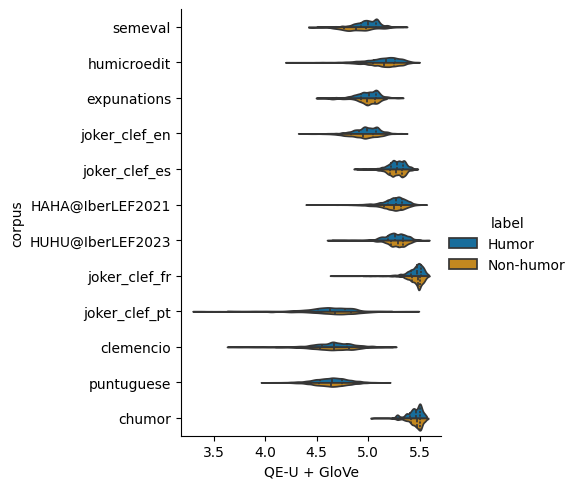

In [7]:
sns.catplot(data=df, x='QE-U + GloVe', y='corpus', hue='label',
            kind='violin', bw_adjust=.5, cut=0, split=True, inner='quart',
            palette='colorblind')
plt.savefig('../../results/img/qe_uncertainty.pdf')

#### Visualize microedition-based corpora

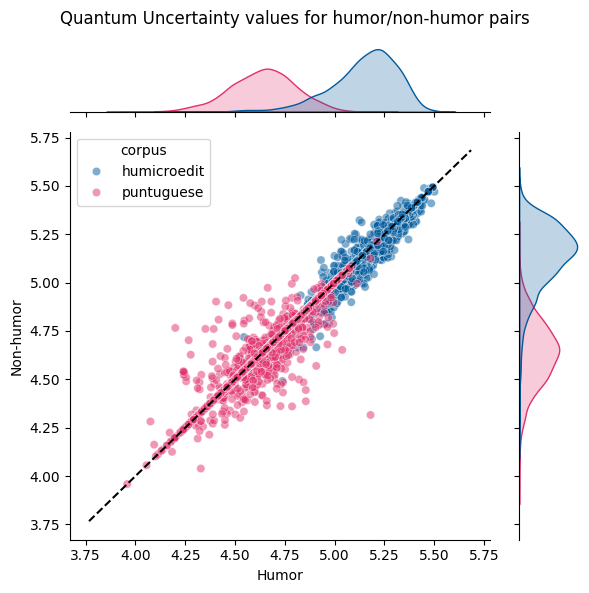

In [7]:
g = sns.jointplot(data=me_dfs['QE-U + GloVe'], x='Humor', y='Non-humor', hue='corpus',
                  palette={'humicroedit': '#005A9C', 'puntuguese': '#E1306C'},
                  alpha=.5)
x0, x1 = g.ax_joint.get_xlim()
y0, y1 = g.ax_joint.get_ylim()
lims = [max(x0, y0), min(x1, y1)]
g.ax_joint.plot(lims, lims, '--k')
g.fig.suptitle('Quantum Uncertainty values for humor/non-humor pairs')
g.fig.tight_layout()
plt.savefig('../../results/img/qe_uncertainty_pairs.pdf')

### Quantum Incongruity

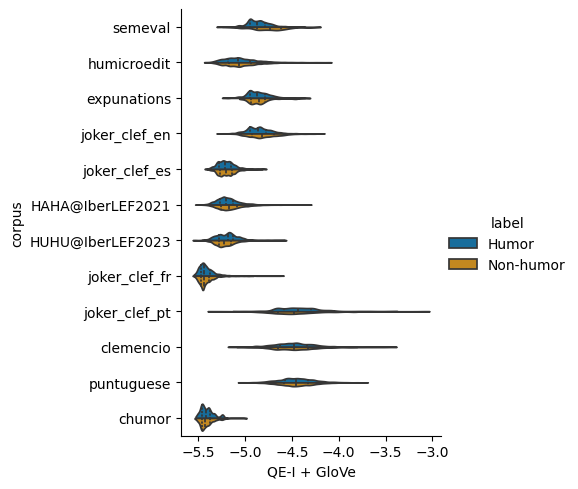

In [9]:
sns.catplot(data=df, x='QE-I + GloVe', y='corpus', hue='label',
            kind='violin', bw_adjust=.5, cut=0, split=True, inner='quart',
            palette='colorblind')
plt.savefig('../../results/img/qe_incongruity.pdf')

#### Visualize microedition-based corpora

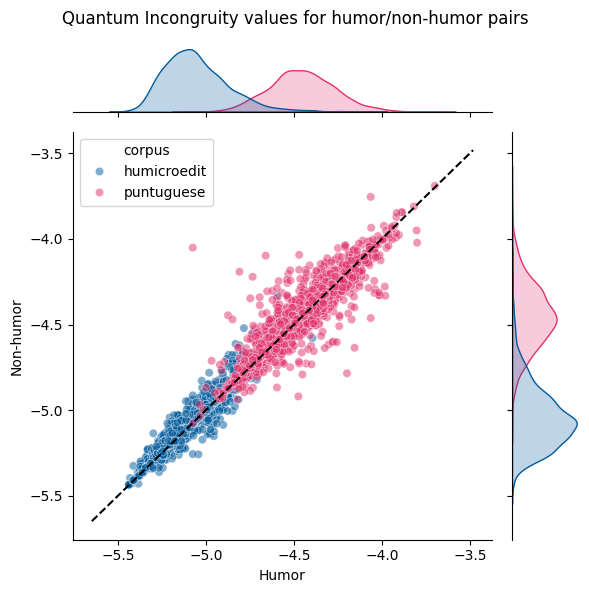

In [8]:
g = sns.jointplot(data=me_dfs['QE-I + GloVe'], x='Humor', y='Non-humor', hue='corpus',
                  palette={'humicroedit': '#005A9C', 'puntuguese': '#E1306C'},
                  alpha=.5)
x0, x1 = g.ax_joint.get_xlim()
y0, y1 = g.ax_joint.get_ylim()
lims = [max(x0, y0), min(x1, y1)]
g.ax_joint.plot(lims, lims, '--k')
g.fig.suptitle('Quantum Incongruity values for humor/non-humor pairs')
g.fig.tight_layout()
plt.savefig('../../results/img/qe_incongruity_pairs.pdf')

### Joint plot

In [11]:
melted_df = df.unpivot(on=['QE-U + GloVe', 'QE-I + GloVe'],
                       index=['index', 'label', 'corpus'], variable_name='metric')
melted_df

index,label,corpus,metric,value
str,str,str,str,f64
"""semeval.het_1""","""Humor""","""semeval""","""QE-U + GloVe""",5.017126
"""semeval.het_2""","""Humor""","""semeval""","""QE-U + GloVe""",4.90941
"""semeval.het_3""","""Non-humor""","""semeval""","""QE-U + GloVe""",4.421414
"""semeval.het_6""","""Non-humor""","""semeval""","""QE-U + GloVe""",4.493063
"""semeval.het_8""","""Humor""","""semeval""","""QE-U + GloVe""",4.944907
…,…,…,…,…
"""chumor.3319""","""Non-humor""","""chumor""","""QE-I + GloVe""",-5.417796
"""chumor.3320""","""Humor""","""chumor""","""QE-I + GloVe""",-5.417796
"""chumor.3327""","""Non-humor""","""chumor""","""QE-I + GloVe""",-5.448898


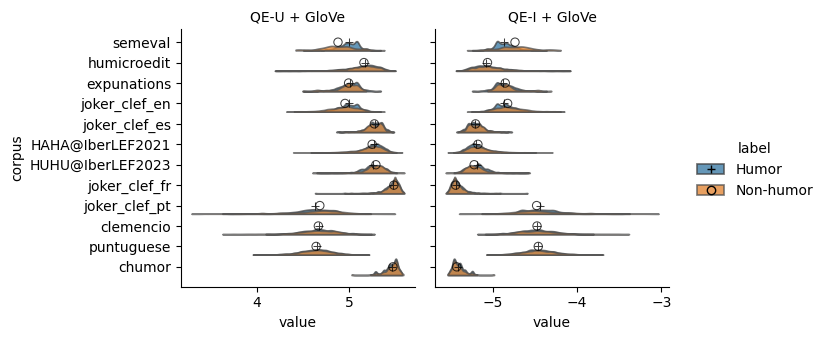

In [12]:
def annotate(data, **kwargs):
    median = data.groupby('corpus')['value'].median()
    median = median.reindex(corpora).dropna()
    ax = plt.gca()
    if kwargs['label'] == 'Humor':
        ax.scatter(x=median, y=np.arange(data['corpus'].nunique()),
                   c='k', marker='+', alpha=.75, linewidths=.75)
    else:
        ax.scatter(x=median, y=np.arange(data['corpus'].nunique()),
                   edgecolors='k', facecolors='none', marker='o',
                   alpha=.75, linewidths=.75)

g = sns.FacetGrid(melted_df, col='metric',
                  col_wrap=2, hue='label',
                  sharex=False, height=3.5, aspect=1)
g.map_dataframe(sns.violinplot, x='value', y='corpus',
                bw_adjust=.5, cut=0, split=True, inner=None,
                alpha=.75)
g.map_dataframe(annotate)
g.set_titles(col_template="{col_name}", row_template="{row_name}")

legend_data = g._legend_data
plus = mlines.Line2D([], [], c='k', marker='+', linestyle='None')
circle = mlines.Line2D([], [], c='k', marker='o', linestyle='None',
                       markerfacecolor='none')
legend_data['Humor'] = (legend_data['Humor'], plus)
legend_data['Non-humor'] = (legend_data['Non-humor'], circle)
g.add_legend(legend_data=legend_data)
g.tight_layout()
plt.savefig('../../results/img/qe_joint_plot.pdf')

## Statistical Tests

### Satistical difference

In [13]:
results = {'metric': list(),
           'corpus': list(),
           'test': list(),
           'statistic': list(),
           'p-value':list()}
for metric in metrics:
    for corpus in df['corpus'].unique(maintain_order=True):
        humor = df.filter((pl.col('corpus') == corpus) & (pl.col('label') == 'Humor'))[metric]
        non_humor = df.filter((pl.col('corpus') == corpus) & (pl.col('label') == 'Non-humor'))[metric]
        test = mannwhitneyu
        paired = False
    
        if corpus in ['humicroedit', 'puntuguese']:
            humor = me_dfs[metric].filter(pl.col('corpus') == corpus)['Humor']
            non_humor = me_dfs[metric].filter(pl.col('corpus') == corpus)['Non-humor']
            test = wilcoxon
            paired = True

        statistic, pvalue = test(humor, non_humor,
                             alternative='greater',
                             nan_policy='omit')
        results['metric'].append(metric)
        results['corpus'].append(corpus)
        results['test'].append(test.__name__)
        results['statistic'].append(statistic)
        results['p-value'].append(pvalue)

results_df = (pl.DataFrame(results)
    .with_columns((pl.col('p-value') < 0.05).alias('different distributions')))

### Correlation

In [14]:
def compute_pearson(row):
    correlation, _ = pearsonr(row['Humor'], row['Non-humor'])
    return correlation

correlation_dfs = [(me_dfs[metric].group_by('corpus')
    .agg(cs.numeric().implode())
    .with_columns(pl.lit(metric).alias('metric')))
    for metric in metrics]
correlation_df = (pl.concat(correlation_dfs)
                 .with_columns(pl.struct(pl.all())
                     .map_elements(compute_pearson, return_dtype=pl.Float64)
                     .alias('correlation'))
                 .select(['corpus', 'metric', 'correlation']))

### Cohen's d

In [15]:
aggs = [expr for metric in metrics
        for expr in (pl.col(metric).mean().alias(f'{metric}_mean'),
                     pl.col(metric).var().alias(f'{metric}_var'))]
aggs.append(pl.len().alias('n'))
stats = (df.group_by(['corpus', 'label']).agg(aggs)
           .pivot('label', index='corpus'))

cohen_d_exprs = []
for metric in metrics:
    pooled_sd = (((pl.col('n_Humor') - 1) * pl.col(f'{metric}_var_Humor') +
                  (pl.col('n_Non-humor') - 1) * pl.col(f'{metric}_var_Non-humor')) /
                 (pl.col('n_Humor') + pl.col('n_Non-humor') - 2)).sqrt()

    cohen_d = (pl.col(f'{metric}_mean_Humor') - pl.col(f'{metric}_mean_Non-humor')) / pooled_sd
    cohen_d_exprs.append(cohen_d.alias(f'cohen_d_{metric}'))

cohen_d_df = (stats.with_columns(cohen_d_exprs)
    .select(pl.col('corpus'), cs.starts_with('cohen_d_'))
    .sort(pl.col('corpus').cast(datasets_enum))
    .unpivot(index='corpus', variable_name='metric', value_name='Cohen\'s d')
    .with_columns(pl.col('metric').str.strip_prefix('cohen_d_')))

### Quantum Uncertainty

#### Statistical difference

In [16]:
with pl.Config(tbl_rows=12):
    display(results_df.filter(pl.col('metric') == 'QE-U + GloVe').select(pl.all().exclude('metric')))

corpus,test,statistic,p-value,different distributions
str,str,f64,f64,bool
"""semeval""","""mannwhitneyu""",90363.0,6.3971e-20,true
"""humicroedit""","""wilcoxon""",1.2756e6,1.6541e-98,true
"""expunations""","""mannwhitneyu""",21555.0,0.101168,false
"""joker_clef_en""","""mannwhitneyu""",659326.0,2.7234e-15,true
"""joker_clef_es""","""mannwhitneyu""",151860.5,0.077015,false
"""HAHA@IberLEF2021""","""mannwhitneyu""",7410531.5,9.6087e-22,true
"""HUHU@IberLEF2023""","""mannwhitneyu""",56735.5,0.944064,false
"""joker_clef_fr""","""mannwhitneyu""",517012.0,0.901985,false
"""joker_clef_pt""","""mannwhitneyu""",1.090746e6,0.965467,false


#### Correlation

In [17]:
correlation_df.filter(pl.col('metric') == 'QE-U + GloVe').select(pl.all().exclude('metric'))

corpus,correlation
str,f64
"""humicroedit""",0.980524
"""puntuguese""",0.925122


#### Cohen's d

In [18]:
with pl.Config(tbl_rows=12):
    display(cohen_d_df.filter(pl.col('metric') == 'QE-U + GloVe').select(pl.all().exclude('metric')))

corpus,Cohen's d
str,f64
"""semeval""",0.923079
"""humicroedit""",0.067705
"""expunations""",0.216757
"""joker_clef_en""",0.40506
"""joker_clef_es""",0.066915
"""HAHA@IberLEF2021""",0.257491
"""HUHU@IberLEF2023""",-0.070713
"""joker_clef_fr""",-0.087407
"""joker_clef_pt""",0.008102


### Quantum Incongruity

#### Statistical difference

In [19]:
with pl.Config(tbl_rows=12):
    display(results_df.filter(pl.col('metric') == 'QE-I + GloVe').select(pl.all().exclude('metric')))

corpus,test,statistic,p-value,different distributions
str,str,f64,f64,bool
"""semeval""","""mannwhitneyu""",36943.0,1.0,false
"""humicroedit""","""wilcoxon""",1.169132e6,1.0,false
"""expunations""","""mannwhitneyu""",18585.0,0.877163,false
"""joker_clef_en""","""mannwhitneyu""",444062.5,1.0,false
"""joker_clef_es""","""mannwhitneyu""",138108.0,0.895626,false
"""HAHA@IberLEF2021""","""mannwhitneyu""",5.674417e6,1.0,false
"""HUHU@IberLEF2023""","""mannwhitneyu""",66886.5,0.017069,true
"""joker_clef_fr""","""mannwhitneyu""",554101.5,0.075095,false
"""joker_clef_pt""","""mannwhitneyu""",1.248207e6,0.08872,false


#### Correlation

In [20]:
correlation_df.filter(pl.col('metric') == 'QE-I + GloVe').select(pl.all().exclude('metric'))

corpus,correlation
str,f64
"""puntuguese""",0.909061
"""humicroedit""",0.980857


#### Cohen's d

In [21]:
with pl.Config(tbl_rows=12):
    display(cohen_d_df.filter(pl.col('metric') == 'QE-I + GloVe').select(pl.all().exclude('metric')))

corpus,Cohen's d
str,f64
"""semeval""",-0.87669
"""humicroedit""",-0.075252
"""expunations""",-0.206334
"""joker_clef_en""",-0.39561
"""joker_clef_es""",-0.065503
"""HAHA@IberLEF2021""",-0.261512
"""HUHU@IberLEF2023""",0.106546
"""joker_clef_fr""",0.088333
"""joker_clef_pt""",-0.025044
